In [1]:
#importing libriaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Dataset Loading
df=pd.read_csv('DataSet.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Data Preprocessing

In [3]:
df.shape

(1048575, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

In [8]:
df["isFraud"].value_counts()

# Percentage
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64

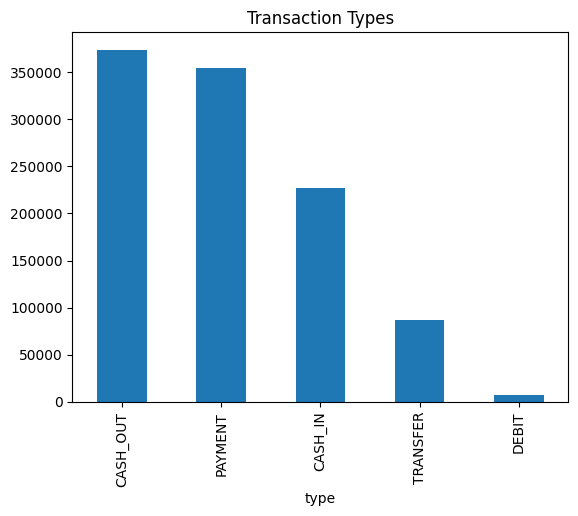

In [9]:
df["type"].value_counts().plot(kind="bar")
plt.title("Transaction Types")
plt.show()

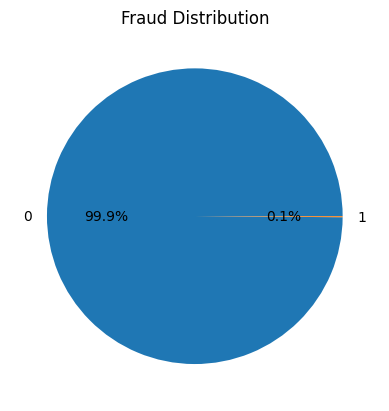

In [10]:
df["isFraud"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Fraud Distribution")
plt.show()

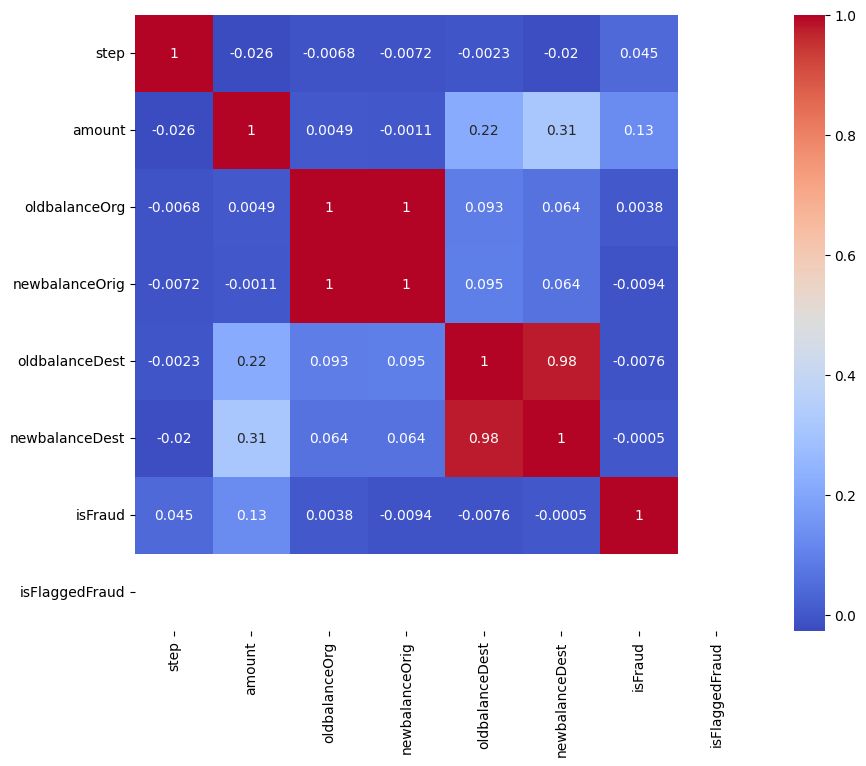

In [11]:
numeric = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")
plt.show()

## Feature Engineering

In [12]:
df = df.drop(["nameOrig","nameDest"], axis=1)
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...
1048570,95,CASH_OUT,132557.35,479803.00,347245.65,484329.37,616886.72,0,0
1048571,95,PAYMENT,9917.36,90545.00,80627.64,0.00,0.00,0,0
1048572,95,PAYMENT,14140.05,20545.00,6404.95,0.00,0.00,0,0
1048573,95,PAYMENT,10020.05,90605.00,80584.95,0.00,0.00,0,0


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])

In [14]:
#Train Test Split
from sklearn.model_selection import train_test_split

X = df.drop("isFraud", axis=1)
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
lr = LogisticRegression(random_state=42, max_iter=1000)

# Train model
lr.fit(X_train, y_train)

# Prediction
lr_pred = lr.predict(X_test)

# Evaluation
print("========== Logistic Regression ==========")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

========== Logistic Regression ==========
Accuracy: 0.9991464606728179

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.89      0.25      0.38       228

    accuracy                           1.00    209715
   macro avg       0.94      0.62      0.69    209715
weighted avg       1.00      1.00      1.00    209715


Confusion Matrix:
[[209480      7]
 [   172     56]]


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=50,      # Reduced from 200
    max_depth=4,          # Reduced from 6
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)


from sklearn.metrics import accuracy_score, classification_report

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9997043606799705
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.99      0.74      0.84       228

    accuracy                           1.00    209715
   macro avg       0.99      0.87      0.92    209715
weighted avg       1.00      1.00      1.00    209715



In [18]:
import joblib

joblib.dump(xgb, "xgboost_model.joblib", compress=9)
joblib.dump(scaler, "scaler.joblib", compress=9)
joblib.dump(le, "label_encoder.joblib", compress=9)

print("Files saved successfully!")

Files saved successfully!
